## 1. Setup Dependencies

In this section we import all required libraries and initialize the main resources used throughout the notebook.

This includes:
- Hugging Face tools for dataset loading and transformer models
- PyTorch for running the RoBERTa classifier
- VADER for sentiment analysis
- spaCy for named entity recognition
- OpenRouter, accessed through the OpenAI-compatible client, for the reasoning layer
- scikit-learn, matplotlib, and seaborn for evaluation and visualization

We also define the main configuration variables such as:
- the dataset split
- the maximum number of rows to use
- the RoBERTa model name
- the OpenRouter model name
- the output file path

Finally, we load the API key from the `.env` file and initialize the NLP tools required by later sections.

In [53]:
# ============================================================
# TEXT-ONLY FAKE NEWS PIPELINE
# Structure:
# 1) Setup dependencies
# 2) Dataset loading
# 3) RoBERTa prediction layer
# 4) VADER + entity extraction
# 5) OpenRouter LLM reasoning layer
# 6) Evaluation
# ============================================================

# ============================================================
# 1. SETUP DEPENDENCIES
# ============================================================

import os
import re
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from openai import OpenAI
import spacy
from tqdm import tqdm

print("--- [1] Setup complete ---")

# ---------------- CONFIG ----------------
HF_DATASET_NAME = "chengxuphd/liar2"
HF_SPLIT = "test"              # "train", "validation", or "test"
MAX_ROWS = 200                 # set None for full split
RANDOM_STATE = 42

TEXT_COLUMN = "statement"
LABEL_COLUMN = "label"

ROBERTA_MODEL_NAME = "hamzab/roberta-fake-news-classification"
OPENROUTER_MODEL = "openai/gpt-4.1-mini"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

load_dotenv()
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
if not openrouter_api_key:
    raise ValueError(
        "Missing OPENROUTER_API_KEY environment variable. "
        "Set it before running the script."
    )

client = OpenAI(
    api_key=openrouter_api_key,
    base_url="https://openrouter.ai/api/v1"
)

# ---------------- LOAD NLP TOOLS ----------------
tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)
roberta_model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME)
roberta_model.to(device)
roberta_model.eval()

vader_analyzer = SentimentIntensityAnalyzer()

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise OSError(
        "spaCy model 'en_core_web_sm' is not installed.\n"
        "Run: python -m spacy download en_core_web_sm"
    )




--- [1] Setup complete ---
Using device: cpu


Loading weights: 100%|█| 201/201 [00:00<00:00, 302.81it/s, Materializing param=roberta.encoder.layer.11.output.dense.we
RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 2. Dataset Loading

Here we load the **LIAR2 dataset** from Hugging Face and prepare it for the text classification task.

Unlike the earlier broader mapping, this version uses a **strict binary setup**:
- `false` → Fake
- `true` → Real

All intermediate labels such as:
- half-true
- mostly-true
- barely-true
- pants-fire

are excluded from the experiment in order to reduce label noise and create a cleaner benchmark.

In this section we also:
- keep the original row index for later inspection
- print the original LIAR2 label counts
- apply the strict label mapping
- remove rows not used by the strict setup
- optionally sample a subset of rows for faster experimentation

In [55]:
# ============================================================
# 2. DATASET LOADING
# ============================================================

print("--- [2] Dataset loading ---")

from datasets import load_dataset
import pandas as pd

HF_DATASET_NAME = "chengxuphd/liar2"
HF_SPLIT = "test"   # "train", "validation", or "test"

TEXT_COLUMN = "statement"
LABEL_COLUMN = "label"

# Set this to True if you want to keep ONLY strict false/true
USE_ONLY_STRICT_TRUE_FALSE = True


def liar2_label_name(x):
    """
    LIAR2 assumed label mapping:
      0 = false
      1 = half-true
      2 = mostly-true
      3 = barely-true
      4 = true
      5 = pants-fire
    """
    mapping = {
        0: "false",
        1: "half-true",
        2: "mostly-true",
        3: "barely-true",
        4: "true",
        5: "pants-fire"
    }
    return mapping.get(int(x), "unknown")


def normalize_label_from_liar2_strict(label_value):
    """
    Strict binary mapping:
      false -> 0
      true  -> 1
      everything else -> None
    """
    if pd.isna(label_value):
        return None

    try:
        x = int(label_value)
    except Exception:
        return None

    if x == 0:
        return 0   # false
    if x == 4:
        return 1   # real / true

    return None


def normalize_label_from_liar2_full(label_value):
    """
    Old broader binary mapping:
      fake = {false, barely-true, pants-fire}
      real = {half-true, mostly-true, true}
    """
    if pd.isna(label_value):
        return None

    try:
        x = int(label_value)
    except Exception:
        return None

    fake_set = {0, 3, 5}
    real_set = {1, 2, 4}

    if x in fake_set:
        return 0
    if x in real_set:
        return 1

    return None


# Load dataset
dataset = load_dataset(HF_DATASET_NAME, split=HF_SPLIT)
full_df = dataset.to_pandas()

# Keep original row index for later inspection
full_df = full_df.reset_index().rename(columns={"index": "orig_idx"})

# Show original label counts before any filtering
print("\nOriginal LIAR2 label counts:")
raw_counts = full_df[LABEL_COLUMN].value_counts().sort_index()
for raw_label, count in raw_counts.items():
    print(f"{raw_label} = {liar2_label_name(raw_label):12s} -> {count}")

# Keep only needed columns for the pipeline
df = full_df[["orig_idx", TEXT_COLUMN, LABEL_COLUMN]].copy()
df.columns = ["orig_idx", "text", "label_raw"]

df["text"] = df["text"].astype(str).str.strip()
df["label_name"] = df["label_raw"].apply(liar2_label_name)

# Choose mapping
if USE_ONLY_STRICT_TRUE_FALSE:
    print("\nUsing STRICT binary mapping: only false vs true")
    df["label"] = df["label_raw"].apply(normalize_label_from_liar2_strict)
else:
    print("\nUsing FULL binary mapping: grouped labels")
    df["label"] = df["label_raw"].apply(normalize_label_from_liar2_full)

# Remove rows not used
df = df[(df["text"] != "") & (df["label"].notna())].reset_index(drop=True)

# Optional sample
if MAX_ROWS is not None:
    df = df.sample(min(MAX_ROWS, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

samples = df.copy()

print(f"\nLoaded split: {HF_SPLIT}")
print(f"Rows used after filtering: {len(samples)}")

print("\nRemaining original labels after filtering:")
print(samples["label_name"].value_counts())

print("\nFinal binary label distribution:")
print(samples["label"].value_counts().sort_index())   # 0=fake, 1=real

--- [2] Dataset loading ---

Original LIAR2 label counts:
0 = false        -> 303
1 = half-true    -> 660
2 = mostly-true  -> 360
3 = barely-true  -> 371
4 = true         -> 343
5 = pants-fire   -> 259

Using STRICT binary mapping: only false vs true

Loaded split: test
Rows used after filtering: 200

Remaining original labels after filtering:
label_name
false    105
true      95
Name: count, dtype: int64

Final binary label distribution:
label
0.0    105
1.0     95
Name: count, dtype: int64


In [56]:

pd.set_option('display.max_colwidth', None)
df.head(10)

,orig_idx,text,label_raw,label_name,label
0,2223,80 percent of the American people haven't gotten a pay raise since the crash.,4,true,1.0
1,1300,Polls show Bernie Sanders would do better than Hillary Clinton in a head-to-head battle against Donald Trump.,4,true,1.0
2,1206,"Ohio replaced lethal injection ""with a system that quickly and humanely rips off the heads of death-row inmates using powerful robotic arms.",0,false,0.0
3,1050,"What was the reality for most Americans during the Obama presidency? Most lost wealth and their incomes fell, particularly for those at the bottom of the ladder.",4,true,1.0
4,286,"Says ABC 7 reported the Santa Clarita high school shooting ""3 weeks in advance.",0,false,0.0
5,1568,"President Trump ""hasn't built any new (border) wall"" during his time in office.",4,true,1.0
6,2112,Nobody in any election in America gets 74% of the votes. Ever. It doesn't happen.,0,false,0.0
7,2178,"Administrative employees at colleges and universities have ""more than doubled over the last 25 years, outpacing the growth of students by more than 2 to 1.",4,true,1.0
8,1832,Pres. Obama's finance team is recommending a . . . 1% tax on all transactions at any financial institution.,0,false,0.0
9,656,"Although the governor doubled the beach fees . . . all the money, as we found out, is all going to an out-of-state company. The state isn't even getting the money for that.",0,false,0.0


In [57]:
df.shape

(200, 5)

## 3. RoBERTa Prediction Layer

This section applies the base **RoBERTa fake-news classifier** to each text statement.

For every input claim, the model returns:
- the predicted label (`fake` or `real`)
- the classifier confidence
- the fake-class probability
- the real-class probability

This classifier output is treated as the **main evidence signal** for the text agent and will later be passed to the LLM reasoning layer.

In [59]:
# ============================================================
# 3. ROBERTA PREDICTION LAYER
# ============================================================

print("--- [3] RoBERTa prediction layer ---")

def classify_with_roberta(text):
    """
    Returns:
      clf_prediction: 'fake' or 'real'
      clf_confidence: top softmax probability
      fake_score: probability fake
      real_score: probability real
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=False
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1).squeeze()

    # Assumption:
    #   index 0 -> fake
    #   index 1 -> real
    fake_score = float(probs[0].item())
    real_score = float(probs[1].item())

    pred_idx = int(torch.argmax(probs).item())
    label = "fake" if pred_idx == 0 else "real"
    confidence = float(probs[pred_idx].item())

    return label, confidence, fake_score, real_score


samples[["clf_prediction", "clf_confidence", "fake_score", "real_score"]] = samples["text"].apply(
    lambda t: pd.Series(classify_with_roberta(t))
)




--- [3] RoBERTa prediction layer ---


## 4. VADER + Entity Extraction

In addition to the classifier output, we extract lightweight linguistic signals from the text.

First, we use **VADER** to compute:
- a sentiment label (`negative`, `neutral`, or `positive`)
- a compound sentiment score

Then, we use **spaCy named entity recognition** to extract entities such as:
- people
- organizations
- locations
- nationalities
- dates
- events

These signals do not verify whether a claim is true or false by themselves, but they provide useful context for the reasoning layer.

In [61]:
# ============================================================
# 4. VADER + ENTITY EXTRACTION
# ============================================================

print("--- [4] VADER + entity extraction ---")

def extract_vader_features(text):
    vs = vader_analyzer.polarity_scores(text)
    compound = float(vs["compound"])

    if compound < -0.05:
        sentiment_label = "negative"
    elif compound > 0.05:
        sentiment_label = "positive"
    else:
        sentiment_label = "neutral"

    return sentiment_label, compound


def extract_entities(text):
    doc = nlp(text)

    allowed_labels = {"PERSON", "ORG", "GPE", "NORP", "DATE", "EVENT"}
    ents = [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in allowed_labels]

    entity_list = [f"{ent_text} ({ent_type})" for ent_text, ent_type in ents[:10]]
    entity_types = sorted(list(set(ent_type for _, ent_type in ents)))
    entity_count = len(ents)

    return entity_list, entity_types, entity_count


samples[["sentiment_label", "sentiment_compound"]] = samples["text"].apply(
    lambda t: pd.Series(extract_vader_features(t))
)

samples[["entities", "entity_types", "entity_count"]] = samples["text"].apply(
    lambda t: pd.Series(extract_entities(t))
)




--- [4] VADER + entity extraction ---


## 5. OpenRouter LLM Reasoning Layer

In this section, we use an LLM through **OpenRouter** to interpret the evidence produced so far.

The LLM receives:
- the original text
- the RoBERTa prediction
- the classifier confidence
- the fake and real scores
- the VADER sentiment result
- the extracted entities

To keep the reasoning controlled, the prompt explicitly tells the LLM to:
- use only the provided evidence
- avoid outside knowledge
- treat the classifier as the strongest signal
- use sentiment and entities only as weak supporting clues

A guardrail is also applied after parsing the response:
- if the classifier confidence is very high, the final decision follows the classifier
- otherwise, the LLM decision may be used if it is valid

This section produces:
- the raw LLM response
- the parsed decision
- the explanation
- the nudge
- a diagnostic flag indicating whether the explanation seems to use forbidden outside-knowledge language

In [63]:
# ============================================================
# 5. OPENROUTER LLM REASONING LAYER (AMPEND-LS Inspired)
# ============================================================

print("--- [5] OpenRouter LLM reasoning layer ---")

def build_ampend_prompt(text, sentiment_label, sentiment_compound, entities, entity_types):
    entities_text = ", ".join(entities) if entities else "None"
    entity_types_text = ", ".join(entity_types) if entity_types else "None"

    return f"""You are an independent fact-checking assistant combining two roles:
1. A senior journalist analyzing rhetorical and persuasive framing
2. A logical analyst evaluating factual plausibility

Your task is to classify the following headline as Real or Fake.

HEADLINE:
"{text}"

AUXILIARY TEXT SIGNALS:
- Sentiment: {sentiment_label} (score: {sentiment_compound:.4f})
- Entity types: {entity_types_text}
- Entities mentioned: {entities_text}

Instructions:
1. You may use your internal world knowledge, but do not pretend you verified external sources in real time.
2. Consider whether the claim is factually plausible and whether it resembles a known hoax, satire pattern, or misleading framing.
3. Consider whether the wording relies on manipulation, hyperbole, fear, outrage, or sensationalism.
4. Do not classify a claim as Fake only because it is political, controversial, or emotionally charged.
5. You must output exactly one final label: Real or Fake.
6. Do not output uncertain, mixed, unknown, or maybe.
7. Even if evidence is incomplete, choose the more likely label.

Respond EXACTLY in this format:
- Decision: Real or Fake
- Explanation: 2 concise sentences
- Nudge: 1 practical suggestion for verification
""".strip()


def query_openrouter(prompt, model=OPENROUTER_MODEL, max_retries=3):
    import time

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                temperature=0,
                max_tokens=200,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You are an independent fact-checking assistant. "
                            "Provide concise, structured outputs."
                        )
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )
            return response.choices[0].message.content.strip()

        except Exception as e:
            print("OpenRouter API error:", repr(e))
            if attempt == max_retries - 1:
                return f"- Decision: Error\n- Explanation: API failed: {str(e)}\n- Nudge: None"
            time.sleep(2)


def parse_field(resp, key):
    import re
    match = re.search(rf"-\s*{key}\s*:\s*(.*)", str(resp), flags=re.IGNORECASE)
    return match.group(1).strip() if match else ""


def normalize_decision_text(d):
    d = str(d).strip().lower()
    if "fake" in d and "real" not in d:
        return "fake"
    if "real" in d and "fake" not in d:
        return "real"
    return None


# --- Quick single test before full loop ---
test_prompt = build_ampend_prompt(
    text=samples.iloc[0]["text"],
    sentiment_label=samples.iloc[0].get("sentiment_label", "Neutral"),
    sentiment_compound=samples.iloc[0].get("sentiment_compound", 0.0),
    entities=samples.iloc[0].get("entities", []),
    entity_types=samples.iloc[0].get("entity_types", [])
)

print("\n--- OpenRouter test call ---")
test_response = query_openrouter(test_prompt)
print(test_response)


# --- Execution Loop ---
llm_responses = []

for _, row in tqdm(samples.iterrows(), total=len(samples), desc="Running AMPEND Agent"):
    prompt = build_ampend_prompt(
        text=row["text"],
        sentiment_label=row.get("sentiment_label", "Neutral"),
        sentiment_compound=row.get("sentiment_compound", 0.0),
        entities=row.get("entities", []),
        entity_types=row.get("entity_types", [])
    )
    llm_responses.append(query_openrouter(prompt))

samples["llm_response"] = llm_responses

# Parse outputs
samples["llm_decision_raw"] = samples["llm_response"].map(lambda r: parse_field(r, "Decision"))
samples["llm_explanation"] = samples["llm_response"].map(lambda r: parse_field(r, "Explanation"))
samples["llm_nudge"] = samples["llm_response"].map(lambda r: parse_field(r, "Nudge"))

# Keep decision as text first
samples["llm_decision"] = samples["llm_decision_raw"].apply(normalize_decision_text)

# Numeric label for evaluation
def llm_decision_to_int(x):
    if x == "fake":
        return 0
    if x == "real":
        return 1
    return None

samples["llm_label"] = samples["llm_decision"].apply(llm_decision_to_int)

# Debug check
print("\n--- LLM parsing check ---")
print(samples[["llm_decision_raw", "llm_decision", "llm_label"]].head(10))
print(samples["llm_decision"].value_counts(dropna=False))

--- [5] OpenRouter LLM reasoning layer ---

--- OpenRouter test call ---
- Decision: Real  
- Explanation: The claim that a significant portion of the American workforce has not received a pay raise since the economic crash is plausible, reflecting ongoing wage stagnation issues. While the exact percentage may vary, the sentiment aligns with documented economic trends and public sentiment regarding income growth.  
- Nudge: Check reputable economic reports or studies from sources like the Bureau of Labor Statistics or economic think tanks for data on wage growth and income trends since the financial crisis.


Running AMPEND Agent: 100%|██████████████████████████████████████████████████████████| 200/200 [06:54<00:00,  2.07s/it]


--- LLM parsing check ---
  llm_decision_raw llm_decision  llm_label
0             Real         real          1
1             Real         real          1
2             Fake         fake          0
3             Real         real          1
4             Fake         fake          0
5             Real         real          1
6             Fake         fake          0
7             Real         real          1
8             Fake         fake          0
9             Real         real          1
llm_decision
real    126
fake     74
Name: count, dtype: int64


## 6. Evaluation

This section compares the performance of:
- the base RoBERTa classifier
- the LLM-enhanced text agent

We compute:
- accuracy
- confusion matrices
- classification reports
- LLM coverage

The goal is to determine whether the reasoning layer provides an improvement over the classifier alone under the strict `false` vs `true` setting.

In [65]:
print(samples[["llm_decision_raw", "llm_label"]].head(10))
print(samples["llm_label"].value_counts(dropna=False))

  llm_decision_raw  llm_label
0             Real          1
1             Real          1
2             Fake          0
3             Real          1
4             Fake          0
5             Real          1
6             Fake          0
7             Real          1
8             Fake          0
9             Real          1
llm_label
1    126
0     74
Name: count, dtype: int64


--- [6] Evaluation ---
RoBERTa Accuracy: 0.585
LLM Accuracy: 0.765
LLM Coverage: 1.000

RoBERTa Confusion Matrix:
 [[60 45]
 [38 57]]

LLM Confusion Matrix:
 [[66 39]
 [ 8 87]]

-----------------------------------------------------
RoBERTa Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.61      0.57      0.59       105
        Real       0.56      0.60      0.58        95

    accuracy                           0.58       200
   macro avg       0.59      0.59      0.58       200
weighted avg       0.59      0.58      0.59       200


-----------------------------------------------------
LLM Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.89      0.63      0.74       105
        Real       0.69      0.92      0.79        95

    accuracy                           0.77       200
   m

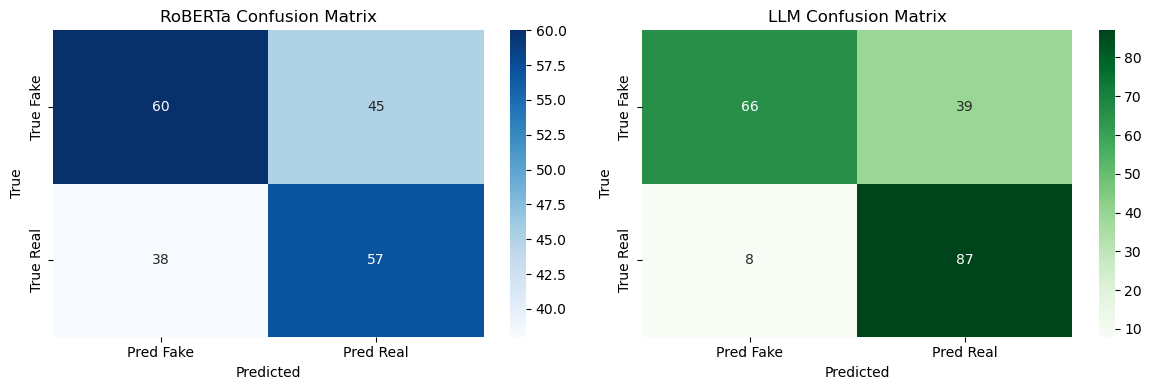

>>> Text-only pipeline complete.


In [75]:
# ============================================================
# 6. EVALUATION
# ============================================================

print("--- [6] Evaluation ---")

def label_to_int(x):
    x = str(x).strip().lower()
    if x == "fake":
        return 0
    if x == "real":
        return 1
    return None

# Ground truth
samples["true_label"] = samples["label"].astype(int)

# RoBERTa branch
samples["clf_label"] = samples["clf_prediction"].apply(label_to_int)

# Keep only rows with valid LLM outputs
llm_clean = samples.dropna(subset=["llm_label"]).copy()
llm_clean["llm_label"] = llm_clean["llm_label"].astype(int)

# Metrics
clf_acc = accuracy_score(samples["true_label"], samples["clf_label"])
llm_acc = accuracy_score(llm_clean["true_label"], llm_clean["llm_label"]) if len(llm_clean) > 0 else float("nan")
llm_cov = len(llm_clean) / len(samples) if len(samples) > 0 else 0.0

print(f"RoBERTa Accuracy: {clf_acc:.3f}")
print(f"LLM Accuracy: {llm_acc:.3f}" if len(llm_clean) > 0 else "LLM Accuracy: nan")
print(f"LLM Coverage: {llm_cov:.3f}")

# Confusion matrices
clf_cm = confusion_matrix(samples["true_label"], samples["clf_label"])
print("\nRoBERTa Confusion Matrix:\n", clf_cm)

if len(llm_clean) > 0:
    llm_cm = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])
    print("\nLLM Confusion Matrix:\n", llm_cm)

# Classification reports
print("\n-----------------------------------------------------")
print("RoBERTa Classification Report")
print("-----------------------------------------------------")
print(classification_report(samples["true_label"], samples["clf_label"], target_names=["Fake", "Real"]))

if len(llm_clean) > 0:
    print("\n-----------------------------------------------------")
    print("LLM Classification Report")
    print("-----------------------------------------------------")
    print(classification_report(llm_clean["true_label"], llm_clean["llm_label"], target_names=["Fake", "Real"]))

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    clf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Fake", "Pred Real"],
    yticklabels=["True Fake", "True Real"],
    ax=axes[0]
)
axes[0].set_title("RoBERTa Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

if len(llm_clean) > 0:
    sns.heatmap(
        llm_cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=["Pred Fake", "Pred Real"],
        yticklabels=["True Fake", "True Real"],
        ax=axes[1]
    )
    axes[1].set_title("LLM Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
else:
    axes[1].axis("off")
    axes[1].set_title("LLM Confusion Matrix unavailable")

plt.tight_layout()
plt.show()

print(">>> Text-only pipeline complete.")

## 7. Dataset Inspection + Example Rows

After running the main pipeline, this section is used to inspect the processed dataset.

We print:
- the dataframe shape
- the column names
- the first rows
- the label distribution
- missing-value counts
- text-length statistics

This helps verify that the dataset was loaded correctly and that all intermediate outputs were generated as expected.

In [77]:
# ============================================================
# DATASET INSPECTION + EXAMPLE ROWS
# ============================================================

print("--- Dataset quick inspection ---")

# Basic shape
print("Shape:", samples.shape)

# Columns
print("\nColumns:")
print(samples.columns.tolist())

# First rows
print("\nFirst 5 rows:")
print(samples.head())



--- Dataset quick inspection ---
Shape: (200, 22)

Columns:
['orig_idx', 'text', 'label_raw', 'label_name', 'label', 'clf_prediction', 'clf_confidence', 'fake_score', 'real_score', 'sentiment_label', 'sentiment_compound', 'entities', 'entity_types', 'entity_count', 'llm_response', 'llm_decision_raw', 'llm_explanation', 'llm_nudge', 'llm_decision', 'llm_label', 'true_label', 'clf_label']

First 5 rows:
   orig_idx  \
0      2223   
1      1300   
2      1206   
3      1050   
4       286   

                                                                                                                                                                text  \
0                                                                                      80 percent of the American people haven't gotten a pay raise since the crash.   
1                                                      Polls show Bernie Sanders would do better than Hillary Clinton in a head-to-head battle against Donald Trump.   


In [79]:
# Label distribution
print("\nLabel distribution (raw integer labels if available):")
if "label_raw" in samples.columns:
    print(samples["label_raw"].value_counts(dropna=False).sort_index())

print("\nBinary label distribution:")
if "label" in samples.columns:
    print(samples["label"].value_counts(dropna=False).sort_index())

# Missing values
print("\nMissing values per column:")
print(samples.isnull().sum())

# Text length statistics
samples["char_len"] = samples["text"].astype(str).apply(len)
samples["word_len"] = samples["text"].astype(str).apply(lambda x: len(x.split()))

print("\nText length stats (characters):")
print(samples["char_len"].describe())

print("\nText length stats (words):")
print(samples["word_len"].describe())


Label distribution (raw integer labels if available):
label_raw
0    105
4     95
Name: count, dtype: int64

Binary label distribution:
label
0.0    105
1.0     95
Name: count, dtype: int64

Missing values per column:
orig_idx              0
text                  0
label_raw             0
label_name            0
label                 0
clf_prediction        0
clf_confidence        0
fake_score            0
real_score            0
sentiment_label       0
sentiment_compound    0
entities              0
entity_types          0
entity_count          0
llm_response          0
llm_decision_raw      0
llm_explanation       0
llm_nudge             0
llm_decision          0
llm_label             0
true_label            0
clf_label             0
dtype: int64

Text length stats (characters):
count    200.0000
mean     107.4100
std       46.0545
min       31.0000
25%       75.0000
50%       97.5000
75%      127.7500
max      290.0000
Name: char_len, dtype: float64

Text length stats (words):
coun

## Error Analysis

This section breaks the results into three groups:

1. RoBERTa correct, LLM wrong  
2. RoBERTa wrong, LLM correct  
3. Both wrong  

For each case, we print:
- the text
- the true label
- the RoBERTa prediction and confidence
- the LLM decision
- the sentiment output
- the extracted entities
- the LLM explanation

This helps us understand when the LLM is helpful, when it hurts performance, and whether it is following the intended bounded-reasoning behavior.

In [82]:
# RoBERTa correct, LLM wrong
case1 = samples[(samples["clf_label"] == samples["true_label"]) & (samples["llm_label"] != samples["true_label"])]

# RoBERTa wrong, LLM correct
case2 = samples[(samples["clf_label"] != samples["true_label"]) & (samples["llm_label"] == samples["true_label"])]

# Both wrong
case3 = samples[(samples["clf_label"] != samples["true_label"]) & (samples["llm_label"] != samples["true_label"])]

for name, df_case in [("RoBERTa correct, LLM wrong", case1),
                      ("RoBERTa wrong, LLM correct", case2),
                      ("Both wrong", case3)]:
    print(f"\n===== {name} =====")
    subset = df_case.head(5)
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"\nExample {i}")
        print("-" * 70)
        print("Text:", row["text"])
        print("True label:", row["true_label"])
        print("RoBERTa:", row["clf_prediction"], "| conf:", row["clf_confidence"])
        print("LLM:", row["llm_decision"])
        print("Sentiment:", row["sentiment_label"], row["sentiment_compound"])
        print("Entities:", row["entities"])
        print("LLM explanation:", row["llm_explanation"])


===== RoBERTa correct, LLM wrong =====

Example 1
----------------------------------------------------------------------
Text: Although the governor doubled the beach fees . . . all the money, as we found out, is all going to an out-of-state company. The state isn't even getting the money for that.
True label: 0
RoBERTa: fake | conf: 0.9992460012435913
LLM: real
Sentiment: neutral 0.0
Entities: []
LLM explanation: The claim about increased beach fees and the money going to an out-of-state company is plausible, as such situations can occur in government contracts and fee structures. The neutral sentiment and lack of sensational language suggest a straightforward reporting of facts rather than manipulation.

Example 2
----------------------------------------------------------------------
Text: Says Barack Obama complained that Democrats continue to ignore blacks except at election time.
True label: 0
RoBERTa: fake | conf: 0.9878761768341064
LLM: real
Sentiment: negative -0.6369
Entities

In [ ]:
print(samples["llm_decision_raw"].value_counts(dropna=False))

In [ ]:
llm_false_positives_real = samples[
    (samples["true_label"] == 0) &   # actually Fake
    (samples["llm_label"] == 1)      # predicted Real
]

print(llm_false_positives_real[["text", "true_label", "llm_label", "llm_explanation"]].head(20).to_string())